In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


In [5]:
using PauliOperators
using Plots
using LinearAlgebra
using Plots.PlotMeasures
using Printf
# using KrylovKit


In [ ]:


function eagle_processor(o::PauliSum{N}; k=10, α=0.01, sequences=[[1, 13], [19, 32], [38, 51], [57, 70], [76, 89], [95, 108], [114, 126]],
    bridges=[[1, 15, 19], [5, 16, 23], [9, 17, 27], [13, 18, 31], [33, 37, 52], [29, 36, 48], [25, 35, 44], [21, 34, 40],
        [38, 53, 57], [42, 54, 61], [46, 55, 65], [50, 56, 69], [71, 75, 90], [67, 74, 86], [63, 73, 82], [59, 72, 78],
        [76, 91, 95], [80, 92, 99], [84, 93, 103], [88, 94, 107], [97, 110, 115], [101, 111, 119], [105, 112, 123],
        [109, 113, 127]]) where {N}

    N == 127 || throw(DimensionMismatch)
    
    need_bridges = true

    generators = Vector{PauliBasis{N}}([])
    parameters = Vector{Float64}([])

    # Loop over trotter steps
    for ki in 1:k
        # e^{i π/2 P2} e^{i π P1 /2}|ψ>
        ## ZZ layer
        for qubit in sequences
            for i in qubit[1]:qubit[2]
                pi = PauliBasis(Pauli(N, Z=[i, i + 1]))
                push!(generators, pi)
                push!(parameters, π/2)
            end
        end
        #bridges
        if need_bridges
            for link in bridges
                pi = PauliBasis(Pauli(N, Z=[link[1], link[2]]))
                push!(generators, pi)
                push!(parameters, π/2)

                pi = PauliBasis(Pauli(N, Z=[link[2], link[3]]))
                push!(generators, pi)
                push!(parameters, π/2)
            end
        else #PBC
            pi = PauliBasis(Pauli(N, Z=[1]))
            push!(generators, pi)
            push!(parameters, π/2)
        end
        ## X layer
        # e^{i αn Pn / 2}
        for i in 1:N
            pi = PauliBasis(Pauli(N, X=[i]))
            # The papers use -X. PauliBasis cannot carry this sign, so put it in the angle.
            push!(generators, pi)
            push!(parameters, -α)
        end
    end
    return (generators, parameters)
end

eagle_processor (generic function with 2 methods)

 α: 0.0000 e:   1.00000000+  0.00000000i
 α: 0.0982 e:   0.99551996+  0.00000000i
 α: 0.1963 e:   0.97947570+  0.00000000i
 α: 0.2945 e:   0.91465182+  0.00000000i
 α: 0.3927 e:   0.85749925+  0.00000000i
 α: 0.4909 e:   0.78796718+  0.00000000i
 α: 0.5890 e:   0.57844950+  0.00000000i
 α: 0.6872 e:   0.40009372+  0.00000000i
 α: 0.7854 e:   0.25289796+  0.00000000i
 α: 0.8836 e:   0.08909735+  0.00000000i
 α: 0.9817 e:   0.01503247+  0.00000000i
 α: 1.0799 e:   0.00000000+  0.00000000i
 α: 1.1781 e:   0.00000000+  0.00000000i
 α: 1.2763 e:   0.00000000+  0.00000000i
 α: 1.3744 e:   0.00000000+  0.00000000i
 α: 1.4726 e:   0.00000000+  0.00000000i
 α: 1.5708 e:   0.00000000+  0.00000000i
 36.411337 seconds (2.42 M allocations: 17.832 GiB, 12.38% gc time, 0.17% compilation time)


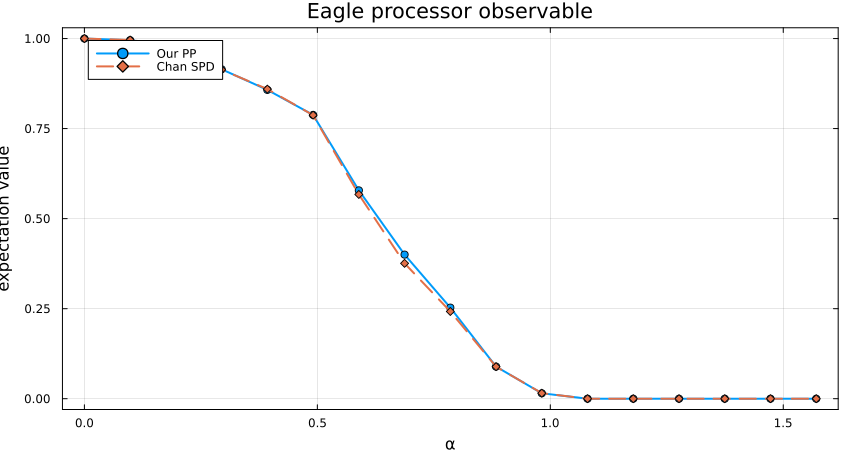

([0.0, 0.09817477042468103, 0.19634954084936207, 0.2945243112740431, 0.39269908169872414, 0.4908738521234052, 0.5890486225480862, 0.6872233929727672, 0.7853981633974483, 0.8835729338221293, 0.9817477042468103, 1.0799224746714913, 1.1780972450961724, 1.2762720155208536, 1.3744467859455345, 1.4726215563702154, 1.5707963267948966], ComplexF64[1.0 + 0.0im, 0.9955199619192684 + 0.0im, 0.9794757002374811 + 0.0im, 0.9146518172368551 + 0.0im, 0.8574992484848935 + 0.0im, 0.7879671764109019 + 0.0im, 0.5784495036080942 + 0.0im, 0.40009371899392415 + 0.0im, 0.25289796333442854 + 0.0im, 0.089097352748619 + 0.0im, 0.015032469436394387 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])

In [28]:
function run(;thresh=1e-3)
  
    N = 127

    ket = Ket{N}(0)
    # o = PauliSum{N}()
    # o = PauliSum(Pauli(N, X=[14,30,32], Y=[10,31], Z=[9,13,18,29,33]))
    o = PauliSum(Pauli(N,Z=[63]))
    angle_steps = collect(0:1:16)
    angles = zeros(Float64, length(angle_steps))
    e = zeros(ComplexF64, length(angle_steps))
    # thresh = 1e-3
    truncation = CoeffTruncation(thresh)
    for (idx, i) in enumerate(angle_steps)
    # for i in 3:3        
        #
        # Uncomment the following to do a serial run
        #
        α = i * π / 32
        generators, parameters = eagle_processor(o, α=α, k=20)
        angles[idx] = α
        
        # ei, _ = UnitaryPruning.dfs_evolution(generators, parameters, 1.0, o, ket, thresh=thresh)
        # ot = deepcopy(o)
        ot = evolve(o, generators, parameters; truncation=truncation)
        ei = expectation_value(ot, ket)
        e[idx] = ei
        @printf(" α: %6.4f e: %12.8f+%12.8fi\n", α, real(ei), imag(ei))
        
    end
    
    p = plot(angles, real.(e),
        label="Our PP",
        marker=:circle,
        lw=2,
        xlabel="α",
        ylabel="expectation value",
        title="Eagle processor observable",
        framestyle=:box,
        legend=:topleft,
        size=(850, 450),
        dpi=100,
    )
    chan = [1, 0.996010052, 0.979475609, 0.913563146, 0.859667434, 0.787234171
,0.567182905
,0.375846242
,0.242234102
,0.089024132
,0.015345074
,0
,0
,0
,0
,0
,0]
    plot!(p, angles, chan[1:length(angles)],
            label="Chan SPD",
            marker=:diamond,
            lw=2,
            ls=:dash, framestyle=:box
        )
    # plot!(p, angles, imag.(e),
    #     label="Im expectation",
    #     marker=:square,
    #     lw=2,
    #     ls=:dash,
    # )
    # savefig(p, "plot_eagle_dfs.pdf")
    display(p)
    return angles, e
end

@time v,e = run(thresh=1e-3)